In [14]:
from collections import deque

def brandes(nodes, adjacency):
    "Compute betweenness centrality in an unweighted graph."
    # Brandes algorithm
    vertex_betweenness = dict((node, 0) for node in nodes)
    for source in nodes:
        visit_order = []                                             # stack of nodes by non-decreasing distance from source
        predecessors = dict((node, []) for node in nodes)            # predecessors on shortest paths from source
        num_shortest_paths = dict((node, 0) for node in nodes)       # sigma: number of shortest paths from source
        num_shortest_paths[source] = 1
        distance = dict((node, -1) for node in nodes)                # distance from source (-1 means not yet reached)
        distance[source] = 0

        # --- Single-source shortest-path search (BFS) ---
        queue = deque([])
        queue.append(source)
        while queue:
            current = queue.popleft()
            visit_order.append(current)
            for neighbor in adjacency[current]:
                if distance[neighbor] < 0:                           # first time reaching neighbor: record its distance
                    queue.append(neighbor)
                    distance[neighbor] = distance[current] + 1
                if distance[neighbor] == distance[current] + 1:      # found a shortest path to neighbor via current
                    num_shortest_paths[neighbor] += num_shortest_paths[current]   # inherit current's path count
                    predecessors[neighbor].append(current)           # remember current as a predecessor of neighbor

        # --- Accumulation: back-propagate dependencies (delta) ---
        dependency = dict((node, 0) for node in nodes)
        while visit_order:
            node = visit_order.pop()                                 # process farthest nodes first
            for predecessor in predecessors[node]:
                share = num_shortest_paths[predecessor] / num_shortest_paths[node]   # fraction of paths through predecessor
                dependency[predecessor] += share * (1 + dependency[node])
            if node != source:
                vertex_betweenness[node] += dependency[node]

    for node in nodes:
        vertex_betweenness[node] = vertex_betweenness[node] / 2      # each path counted from both endpoints, so halve
    return vertex_betweenness

In [15]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np
# G=nx.gnp_random_graph(4,0.3)
G=nx.Graph()
G.add_nodes_from(range(6))
G.add_edge(0,1)
G.add_edge(0,2)
G.add_edge(1,2)
G.add_edge(2,3)
G.add_edge(3,4)
G.add_edge(3,5)
G.add_edge(4,5)

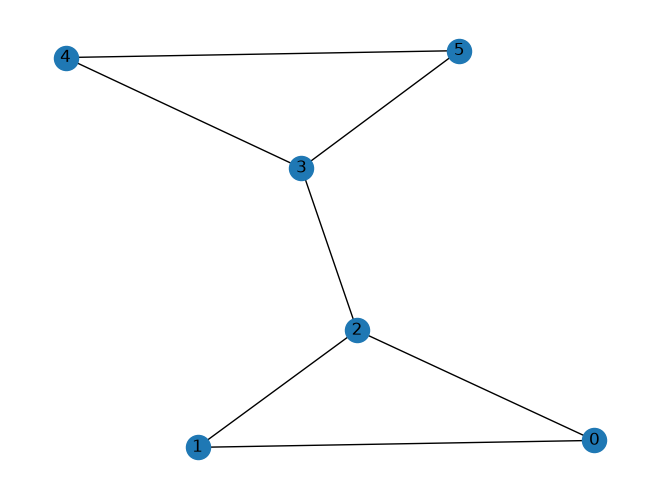

In [16]:
nx.draw(G, with_labels=True)

In [17]:
# List of nodes (vertices) in the graph
nodes = list(G.nodes())

# List of edges in the graph
edges = list(G.edges())
print("Number of edges:", len(edges))

# Build an adjacency dictionary: node -> list of neighboring nodes.
# The graph is undirected, so each edge is added in both directions.
adjacency = dict((node, []) for node in nodes)
for (u, v) in edges:
    adjacency[u].append(v)
    adjacency[v].append(u)

Number of edges: 7


In [18]:
print(nodes)
print(adjacency)

[0, 1, 2, 3, 4, 5]
{0: [1, 2], 1: [0, 2], 2: [0, 1, 3], 3: [2, 4, 5], 4: [3, 5], 5: [3, 4]}


In [19]:
brandes(nodes, adjacency)

{0: 0.0, 1: 0.0, 2: 6.0, 3: 6.0, 4: 0.0, 5: 0.0}

In [20]:
# --- Test cases ---

import networkx as nx

def check_vertex(edge_list, n):
    g = nx.Graph()
    g.add_nodes_from(range(n))
    g.add_edges_from(edge_list)
    adjacency = {node: list(g[node]) for node in g.nodes()}
    got = brandes(list(g.nodes()), adjacency)
    expected = nx.betweenness_centrality(g, normalized=False)
    assert all(abs(got[v] - expected[v]) < 1e-9 for v in g.nodes()), (got, expected)

check_vertex([(0,1),(0,2),(1,2),(2,3),(3,4),(3,5),(4,5)], 6)  # unique shortest paths
check_vertex([(0,1),(1,2),(2,3),(3,0)], 4)                    # 4-cycle (ties)
check_vertex([(0,1),(0,2),(1,3),(2,3)], 4)                    # diamond (ties)
check_vertex([(0,1),(1,2),(2,3),(3,4),(4,5),(5,0)], 6)        # 6-cycle (ties)
check_vertex([(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)], 4)        # K4 (ties)
print("All vertex betweenness tests passed.")


All vertex betweenness tests passed.
